In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Data/retail_sales_dataset.csv")

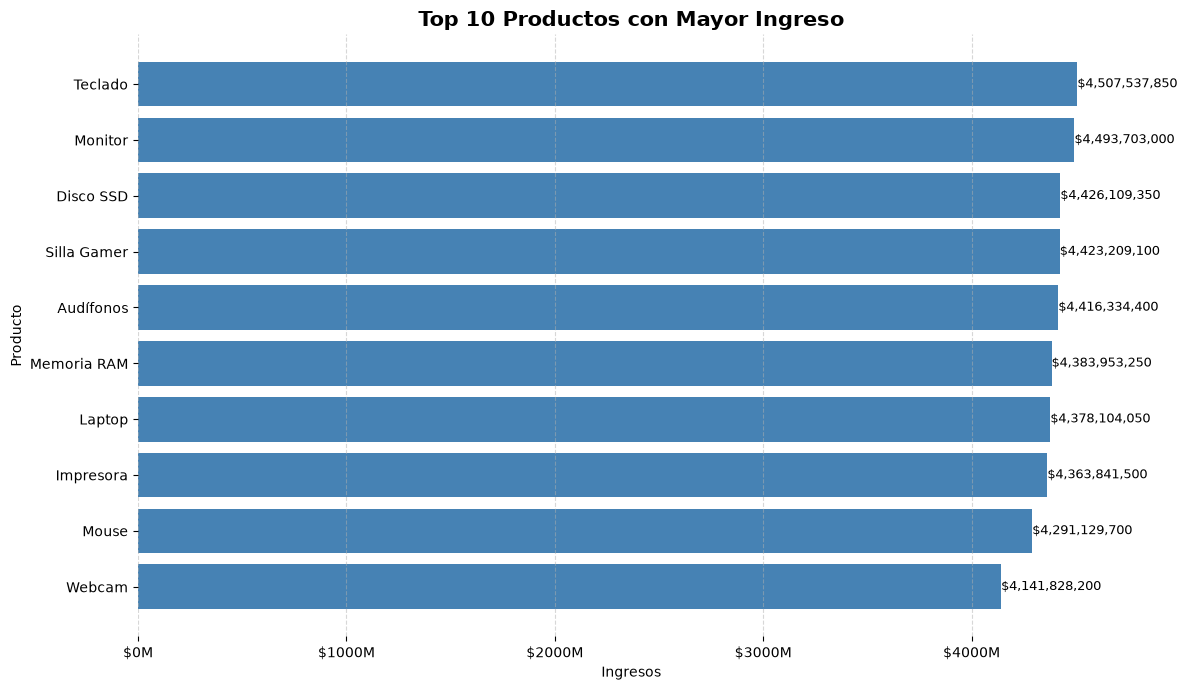

In [33]:
from matplotlib.ticker import FuncFormatter

ventas_producto = (
    df.groupby("Producto")["Total Venta"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,7))

plt.barh(
    ventas_producto.index,
    ventas_producto.values,
    color="steelblue"
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Productos con Mayor Ingreso",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Ingresos")
plt.ylabel("Producto")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.0f}M")
)

for i, valor in enumerate(ventas_producto.values):
    plt.text(
        valor,
        i,
        f"${valor:,.0f}",
        va="center",
        fontsize=9
    )

plt.box(False)

plt.tight_layout()
plt.show()

### Interpretación

- Los productos tecnológicos presentan ingresos muy similares entre sí.
- El producto con mayor facturación fue **Teclado**.
- No existe una diferencia significativa entre el primer y el décimo lugar, lo que sugiere una distribución de ventas equilibrada entre las categorías del negocio.
- Se recomienda profundizar el análisis evaluando la cantidad vendida y el margen de utilidad por producto para identificar cuáles generan mayor rentabilidad.

In [4]:
ventas_ciudad = (
    df.groupby("Ciudad")["Total Venta"]
      .sum()
      .sort_values()
)

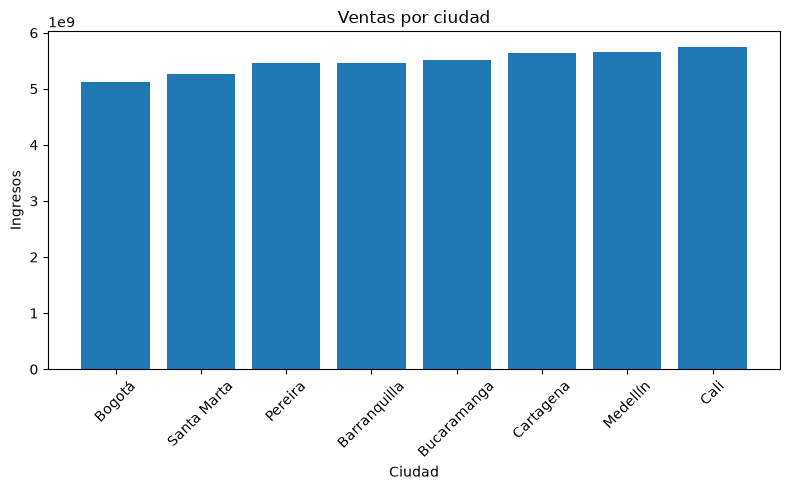

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    ventas_ciudad.index,
    ventas_ciudad.values
)

plt.title("Ventas por ciudad")

plt.xlabel("Ciudad")

plt.ylabel("Ingresos")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Interpretación

Se observa que algunas ciudades concentran una mayor participación en las ventas.

Este análisis ayuda a identificar mercados prioritarios y posibles oportunidades de crecimiento en ciudades con menor desempeño.

In [6]:
ventas_categoria = (
    df.groupby("Categoría")["Total Venta"]
      .sum()
      .sort_values(ascending=False)
)

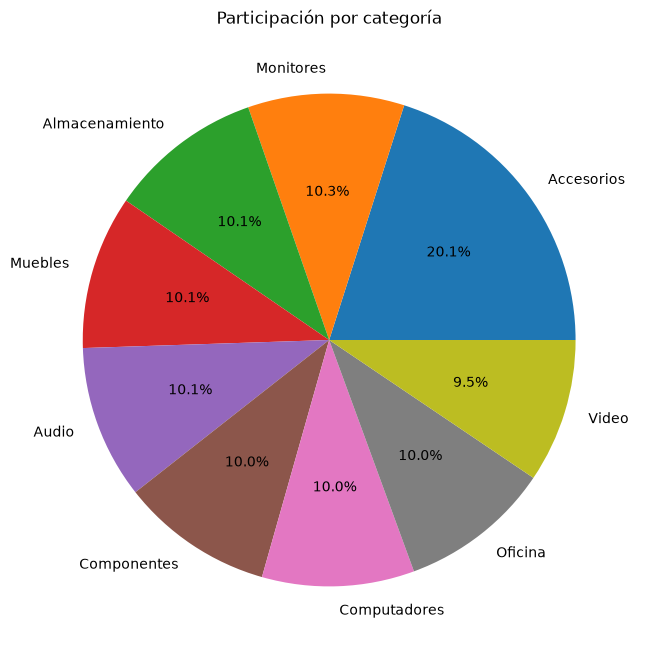

In [7]:
plt.figure(figsize=(8,8))

plt.pie(
    ventas_categoria,
    labels=ventas_categoria.index,
    autopct="%1.1f%%"
)

plt.title("Participación por categoría")

plt.show()

# Interpretación

La distribución porcentual permite identificar cuáles categorías generan la mayor proporción de ingresos del negocio, facilitando la toma de decisiones sobre inversión y abastecimiento.

In [8]:
metodos = df["Método Pago"].value_counts()

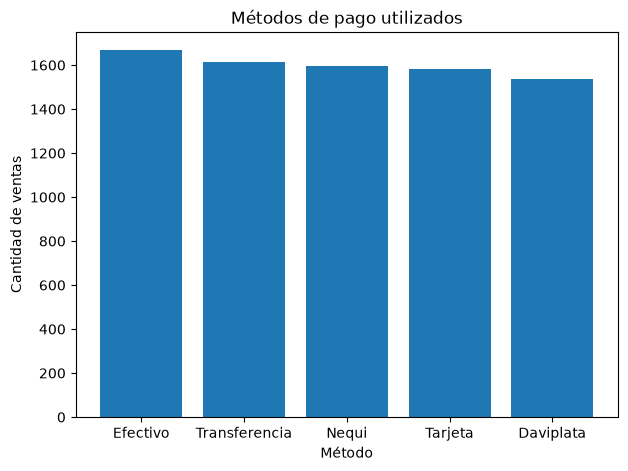

In [9]:
plt.figure(figsize=(7,5))

plt.bar(
    metodos.index,
    metodos.values
)

plt.title("Métodos de pago utilizados")

plt.xlabel("Método")

plt.ylabel("Cantidad de ventas")

plt.show()

# Interpretación

El método de pago más utilizado refleja la preferencia de los clientes y puede servir para optimizar procesos de pago o establecer alianzas con entidades financieras.

In [10]:
df["Fecha"] = pd.to_datetime(df["Fecha"])

df["Año"] = df["Fecha"].dt.year

In [11]:
ventas_año = (
    df.groupby("Año")["Total Venta"]
      .sum()
)

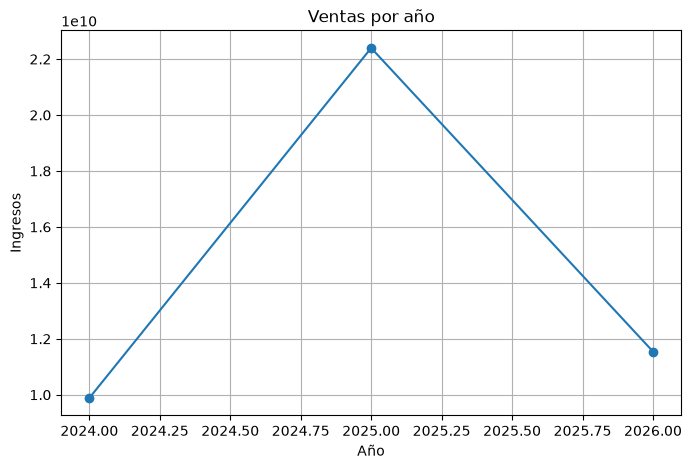

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    ventas_año.index,
    ventas_año.values,
    marker="o"
)

plt.title("Ventas por año")

plt.xlabel("Año")

plt.ylabel("Ingresos")

plt.grid()

plt.show()

# Interpretación

La evolución anual permite identificar tendencias de crecimiento o disminución en las ventas, facilitando la evaluación del desempeño del negocio a lo largo del tiempo.